# palantir

In [1]:
### conda activate porject_lung_exercise_R
### based on https://palantir.readthedocs.io/en/latest/notebooks/Palantir_sample_notebook.html

import palantir
import scanpy as sc
import pandas as pd
import os
import numpy as np

# Plotting
import matplotlib
import matplotlib.pyplot as plt

# warnings
import warnings
from numba.core.errors import NumbaDeprecationWarning

warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)

# Inline plotting
%matplotlib inline

In [2]:
ad = sc.read_h5ad('/home/sjcho/projects/AT2_MHC2/code_for_publish/20250806_publish/lineage_tracing/outs/full_so.h5ad')
save_path = '/home/sjcho/projects/AT2_MHC2/code_for_publish/20250806_publish/lineage_tracing/outs/palantir'

In [7]:
ad.obsm['X_pca'].shape

(3144, 50)

In [3]:
alv_cols = {
    'AT2': '#8192ef',
    'tAT2': '#dfd13a',
    'AT1': '#f66b07',
    'AT2.IFN': '#000000',
    'AT2.prolif.': '#8bd690'
}

In [4]:
desired_categories = ['AT2', 'tAT2', 'AT1', 'AT2.IFN', 'AT2.prolif.']

ad.obs['majority_voting'] = pd.Categorical(
    ad.obs['majority_voting'],
    categories=desired_categories,
    ordered=False
)

In [5]:
ad.obs['majority_voting']

lt_30dpi_dAT2_AAACCAAAGGATCTAT-1      AT2
lt_30dpi_dAT2_AAACCCGCAGCACCTT-1      AT1
lt_30dpi_dAT2_AAACCCGCATAATCTC-1      AT2
lt_30dpi_dAT2_AAACGTAAGCCCTACC-1      AT2
lt_30dpi_dAT2_AAACTCACAATCGCTC-1      AT2
                                     ... 
lt_30dpi_floxed_TGTGCAATCATGCTCT-1    AT2
lt_30dpi_floxed_TGTGCCAGTAGTCCTG-1    AT1
lt_30dpi_floxed_TGTGCCAGTTAATCCA-1    AT2
lt_30dpi_floxed_TGTGGTTGTGAGTCCC-1    AT1
lt_30dpi_floxed_TGTGTTGAGTAGAGAC-1    AT2
Name: majority_voting, Length: 3144, dtype: category
Categories (5, object): ['AT2', 'tAT2', 'AT1', 'AT2.IFN', 'AT2.prolif.']

/home/sjcho/.conda/envs/project_lung_exercise_R/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


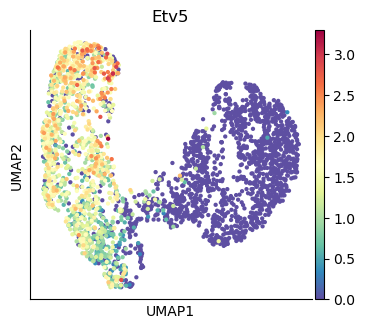

In [6]:
dm_res = palantir.utils.run_diffusion_maps(ad, n_components=5)
ms_data = palantir.utils.determine_multiscale_space(ad)
from matplotlib import rcParams
rcParams["figure.figsize"] = (4, 3.5)

fig = sc.pl.umap(ad, color='Etv5', sort_order = True, return_fig=True)

fig.savefig(save_path + '/Etv5.pdf', bbox_inches='tight')
fig.savefig(save_path + '/Etv5.png', dpi = 500)

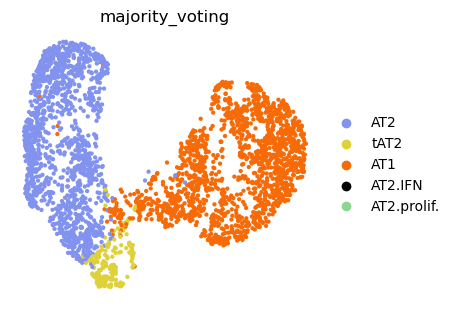

In [7]:
gene_name = 'Etv5'
gene_idx = ad.var_names.get_loc(gene_name)

fig = sc.pl.embedding(
    ad,
    basis="umap",
    frameon=False,
    color='majority_voting',
    palette=alv_cols, 
    return_fig=True
)
fig.savefig(save_path + '/umap_celltype.pdf', bbox_inches='tight')
fig.savefig(save_path + '/umap_celltype.png', dpi = 500)

In [8]:
start_cell = 'lt_30dpi_dAT2_CTCGATCCAAACCGTG-1' # because it has the most highest Etv5 expression in cluster 1
# cluster 1 has the highest Etv5 average expression among all clusters

pr_res = palantir.core.run_palantir(
    ad, start_cell
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.008533680438995361 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.16865121523539225 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


In [9]:
ad.obsm['palantir_fate_probabilities'].to_csv(save_path + '/palantir_fate_probabilities.csv')
ad.obs['palantir_pseudotime'].to_csv(save_path + '/palantir_pseudotime.csv')
ad.obs['palantir_entropy'].to_csv(save_path + '/palantir_entropy.csv')

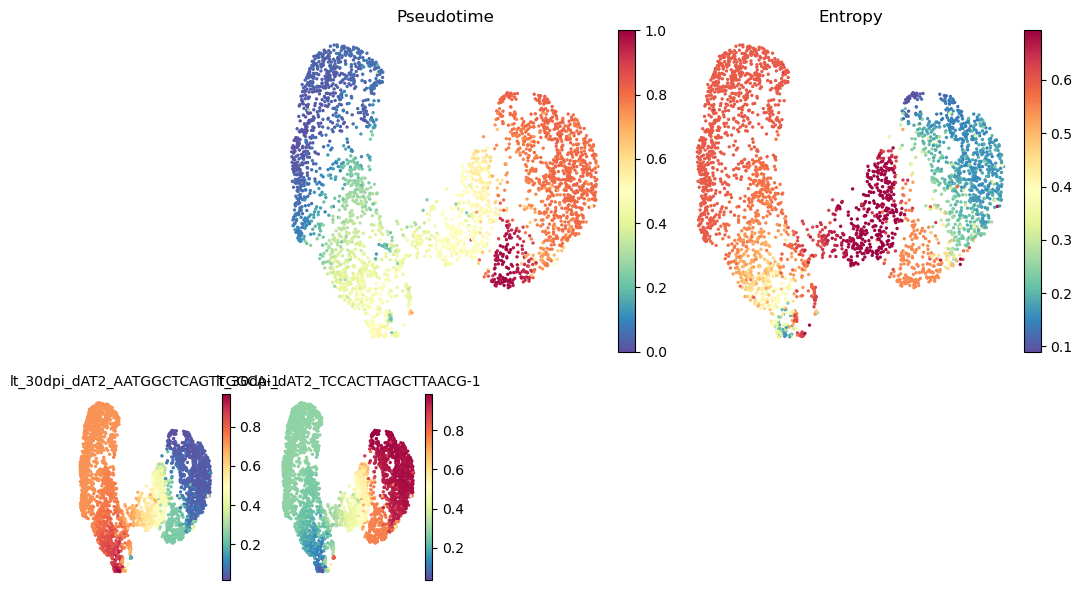

In [10]:
figs = palantir.plot.plot_palantir_results(ad, s=2)
figs.show()
figs.savefig(save_path + '/palantir_results.pdf', bbox_inches='tight')
figs.savefig(save_path + '/palantir_results.png', dpi = 500)

In [11]:
masks = palantir.presults.select_branch_cells(ad, q=0.01, eps=0.01) # default parameter

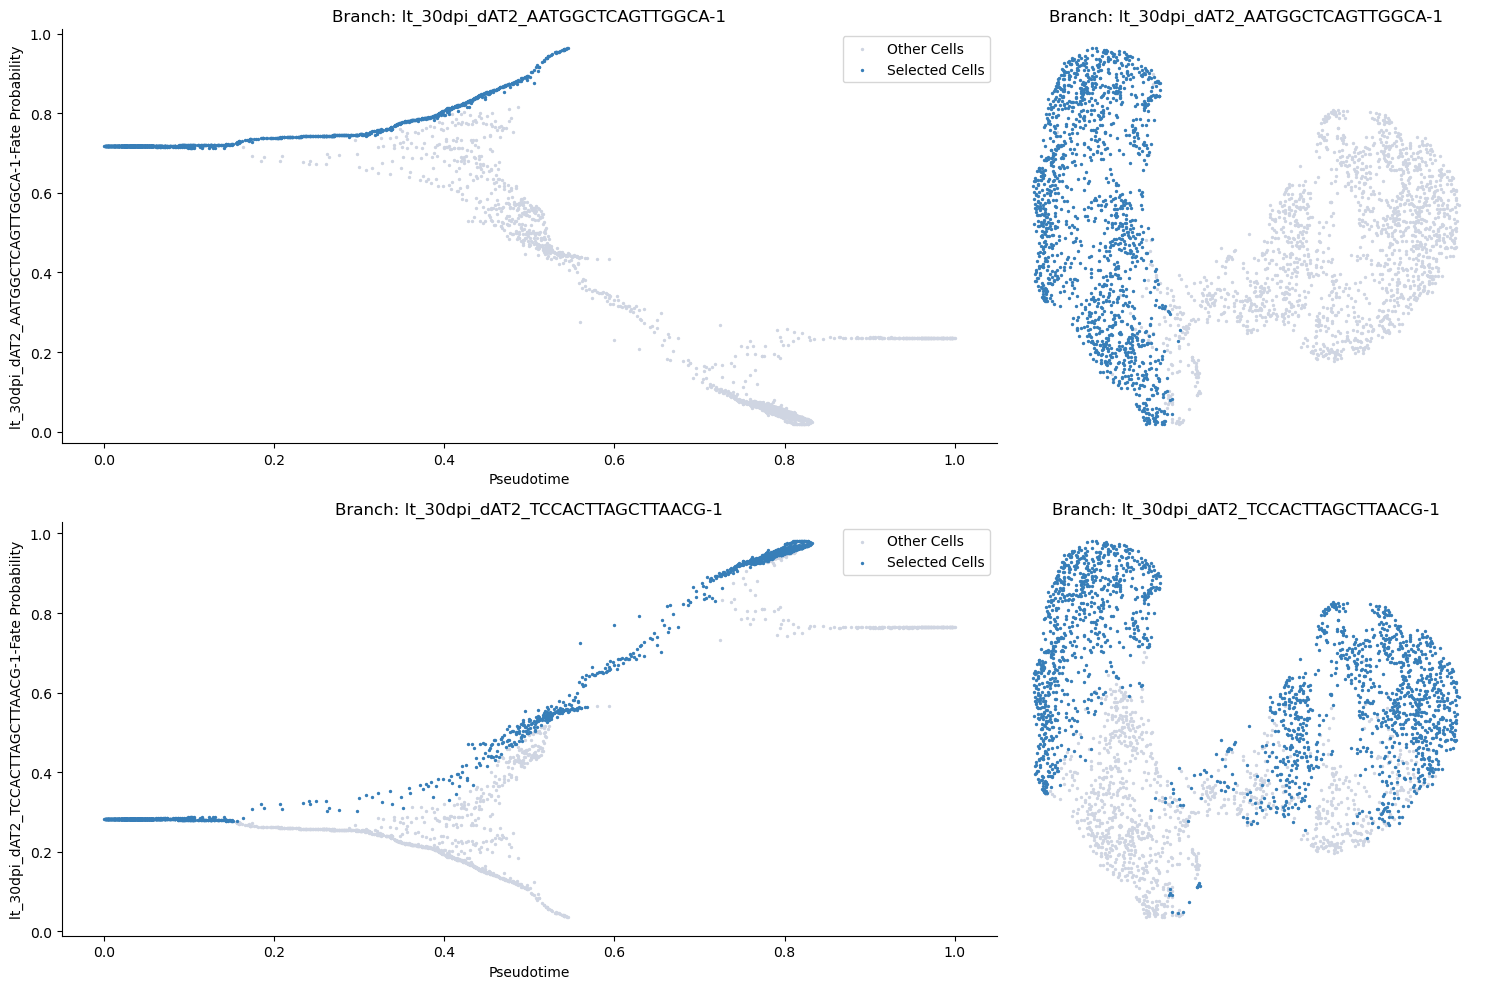

In [13]:
figs = palantir.plot.plot_branch_selection(ad, s= 2)
figs.show()
figs.savefig(save_path + '/branch_selection.pdf', bbox_inches='tight')
figs.savefig(save_path + '/branch_selection.png', dpi = 500)

ad.obsm['branch_masks'].to_csv(save_path + '/branch_masks.csv')